In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Caricamento Dati
try:
    df = pd.read_csv('data.csv')
    # Pulizia nomi colonne (rimuove spazi invisibili che spesso causano errori)
    df.columns = [col.strip() for col in df.columns]
    print("Dataset caricato correttamente")
except FileNotFoundError:
    print("Errore: Il file 'data.csv' non è nella cartella del progetto.")

# 2. Generazione Feature Sintetiche
if 'df' in locals():
    np.random.seed(42)
    
    
    df['Days_Past_Due'] = np.where(
        df['Bankrupt?'] == 1,
        np.random.normal(loc=45, scale=25, size=len(df)), # Abbassato il ritardo e aumentata la varianza
        np.random.normal(loc=15, scale=15, size=len(df))  # Alzato il ritardo per le sane
)
    
    df['Unpaid_Invoices_Ratio'] = np.where(
        df['Bankrupt?'] == 1,
        np.random.beta(a=2, b=5, size=len(df)), 
        np.random.beta(a=1, b=10, size=len(df)) 
)

    df['Days_Past_Due'] = np.maximum(0, df['Days_Past_Due']).astype(int)
    
    print("Feature comportamentali create")
    
    # Visualizzazione dei risultati
    print("\nMedia dei ritardi per categoria (0=Sane, 1=Fallite):")
    display(df[['Bankrupt?', 'Days_Past_Due', 'Unpaid_Invoices_Ratio']].groupby('Bankrupt?').mean())

Dataset caricato correttamente
Feature comportamentali create

Media dei ritardi per categoria (0=Sane, 1=Fallite):


,Days_Past_Due,Unpaid_Invoices_Ratio
Bankrupt?,,
0,15.813608,0.089562
1,43.481818,0.275677


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

# 1. Selezione delle Feature
# Usiamo feature sintetiche + alcune feature finanziarie dal dataset originale
features = ['Days_Past_Due', 'Unpaid_Invoices_Ratio', 'Net Value Per Share (A)', 'Debt ratio %']
X = df[features]
y = df['Bankrupt?']

# 2. Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scaling dei dati
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Addestramento Modello
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)

# 5. Valutazione
y_pred = model.predict(X_test_scaled)
auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])

print(f"Modello addestrato. Area sotto la curva ROC (AUC): {auc:.2f}")
print("\nReport di Classificazione:")
print(classification_report(y_test, y_pred))

Modello addestrato. Area sotto la curva ROC (AUC): 0.94

Report di Classificazione:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1320
           1       0.28      0.86      0.42        44

    accuracy                           0.92      1364
   macro avg       0.64      0.89      0.69      1364
weighted avg       0.97      0.92      0.94      1364



C:\Users\gianl\AppData\Local\Temp\ipykernel_1884\3208645336.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled, feature_names=features)


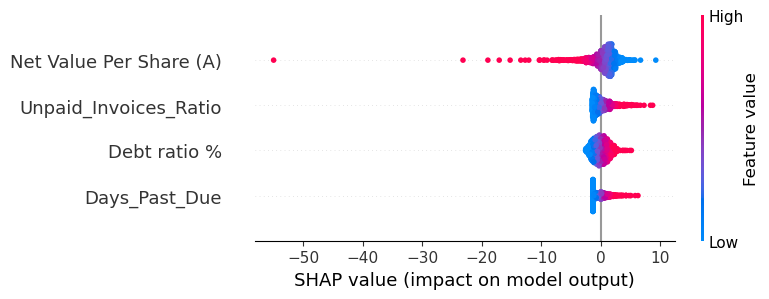

In [5]:
import shap

# Calcolo dei valori SHAP per spiegare il modello
explainer = shap.LinearExplainer(model, X_train_scaled, feature_names=features)
shap_values = explainer.shap_values(X_test_scaled)

# Visualizzazione dell'importanza delle variabili
shap.summary_plot(shap_values, X_test_scaled, feature_names=features)

In [12]:
# Forza la reinstallazione pulita di NumPy e SHAP nel kernel corrente
%pip uninstall -y numpy shap
%pip install numpy==1.26.4 shap --force-reinstall

Found existing installation: numpy 1.26.0Note: you may need to restart the kernel to use updated packages.

Uninstalling numpy-1.26.0:
  Successfully uninstalled numpy-1.26.0
Found existing installation: shap 0.51.0
Uninstalling shap-0.51.0:
  Successfully uninstalled shap-0.51.0
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     --------------------------------- ------ 51.2/61.0 kB ? eta -:--:--
     -------------------------------------- 61.0/61.0 kB 651.3 kB/s eta 0:00:00
  Using cached shap-0.51.0-cp311-cp311-win_amd64.whl.metadata (26 kB)
INFO: pip is looking at multiple versions of shap to determine which version is compatible with other requirements. This could take a while.
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda-repo-cli 1.0.41 requires requests_mock, which is not installed.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
transformers 2.1.1 requires sentencepiece, which is not installed.
conda-repo-cli 1.0.41 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.41 requires nbformat==5.4.0, but you have nbformat 5.7.0 which is incompatible.
conda-repo-cli 1.0.41 requires python-dateutil==2.8.2, but you have python-dateutil 2.9.0.post0 which is incompatible.
conda-repo-cli 1.0.41 requires requests==2.28.1, but you have requests 2.31.0 which is incompatible.
python-lsp-black 1.2.1 requires black>=22.3.0, but you have black 0.0 which is incompati

In [ ]:
!pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 640.0 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 804.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---- ----------------------------------- 61.4/554.9 kB 1.7 MB/s eta 0:00:01
   ---------------------- ----------------- 307.2/554.9 kB 3.8 MB/s eta 0:00:01
   ------------------------------ --------- 419.8/554.9 kB 3.3 MB/s eta 0:00:01
   ------------------------------------- -- 522.2/554.9 kB 3.7 MB/s eta 0:00:01
   ----------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
transformers 2.1.1 requires sentencepiece, which is not installed.
tensorflow-intel 2.17.0 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.4.4 which is incompatible.
